Bloque de Montaje de Google Drive

Bloque de Rutas y Configuraciones Ajustadas

In [24]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils import class_weight
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import time
import shutil # Necesario para la copia
import zipfile
import io

from google.colab import drive

# 🚨 SOLUCIÓN: LIMPIAR EL DIRECTORIO ANTES DE MONTAR 🚨
mountpoint = '/content/drive'

# Verifica si el directorio existe y si tiene contenido
if os.path.isdir(mountpoint) and os.listdir(mountpoint):
    print(f"⚠️ Eliminando contenido residual de {mountpoint}...")
    # Elimina forzadamente el contenido (excepto el directorio principal)
    # Solo en caso de que un desmontaje previo haya dejado archivos
    try:
        shutil.rmtree(mountpoint)
        os.makedirs(mountpoint) # Vuelve a crear el directorio vacío
        print("✅ Directorio limpiado.")
    except Exception as e:
        print(f"❌ Error al limpiar: {e}. Intentando solo desmontar.")

# 1. Monta Google Drive
try:
    drive.mount(mountpoint, force_remount=True)
    print("✅ Google Drive montado y librerías cargadas.")
except Exception as e:
    # Si la limpieza no funcionó, intenta el desmontaje formal
    print("El montaje falló. Intentando desmontar y reintentar...")
    drive.unmount(mountpoint)
    drive.mount(mountpoint, force_remount=True)
    print("✅ Google Drive re-montado.")

# --- 2. COPIA DE DATOS Y CONFIGURACIÓN GLOBAL ---

# !!! 🚨 RUTA ACTUAL DE TU DATASET AUMENTADO EN DRIVE 🚨 !!!
DRIVE_PATH_AUMENTADO = r'/content/drive/MyDrive/Datasets_Ulceras/Dataset 3'
# !!! 🚨 RUTA RÁPIDA DE DESTINO 🚨 !!!
LOCAL_PATH = r'/content/Dataset 3/'

print("\nIniciando copia del dataset básico (1,200 imágenes) de Drive a la memoria local de Colab...")
print("⚠️ Esto puede tardar varios minutos (5-15 min) pero acelerará el entrenamiento.")

# Crea la carpeta de destino local
os.makedirs(LOCAL_PATH, exist_ok=True)

try:
    # Usa rsync (sistema Linux subyacente de Colab) para una copia más robusta
    # La salida de este comando puede ser larga
    !rsync -a "$DRIVE_PATH_AUMENTADO/" "$LOCAL_PATH"

    print("\n✅ COPIA EXITOSA. El dataset ahora está en la memoria rápida.")
    # 🚨 DEFINICIÓN GLOBAL DE LA RUTA DEL DATASET 🚨
    DATASET_PATH_GLOBAL = LOCAL_PATH

except Exception as e:
    print(f"\n❌ ERROR en la copia: {e}")
    print("Se usará la ruta de Drive, que es más lenta.")
    DATASET_PATH_GLOBAL = DRIVE_PATH_AUMENTADO

# --- CONFIGURACIÓN DE PARÁMETROS ---

# !!! 🚨 RUTA DE LA IMAGEN DE PRUEBA EN GOOGLE DRIVE 🚨 !!!
RUTA_IMAGEN_NUEVA = r'/content/drive/MyDrive/Datasets_Ulceras/stage_4_2274.jpg'

BATCH_SIZE = 32
VALIDATION_SPLIT = 0.2

# ÉPOCAS RECOMENDADAS CON MÁS DATOS (30 TOTAL)
initial_epochs = 10
fine_tune_epochs = 20
TOTAL_EPOCHS = initial_epochs + fine_tune_epochs

# Hyperparámetros probados
fine_tune_learning_rate = 5e-6
DROPOUT_RATE = 0.6

# Diccionario de Modelos (Define MODEL_SETTINGS)
MODEL_SETTINGS = {
    "EfficientNetB0": {
        "func": tf.keras.applications.EfficientNetB0,
        "size": (224, 224),
        "preprocess": tf.keras.applications.efficientnet.preprocess_input
    }
}

print(f"Configuración de épocas: {TOTAL_EPOCHS}. Dropout: {DROPOUT_RATE}. LR: {fine_tune_learning_rate}")
print(f"Ruta de entrenamiento: {DATASET_PATH_GLOBAL}")

⚠️ Eliminando contenido residual de /content/drive...
❌ Error al limpiar: [Errno 125] Operation canceled: '/content/drive/.Encrypted/MyDrive'. Intentando solo desmontar.
Mounted at /content/drive
✅ Google Drive montado y librerías cargadas.

Iniciando copia del dataset básico (1,200 imágenes) de Drive a la memoria local de Colab...
⚠️ Esto puede tardar varios minutos (5-15 min) pero acelerará el entrenamiento.
rsync: [sender] change_dir "/content/drive/MyDrive/Datasets_Ulceras/Dataset 3" failed: No such file or directory (2)
rsync error: some files/attrs were not transferred (see previous errors) (code 23) at main.c(1356) [sender=3.2.7]

✅ COPIA EXITOSA. El dataset ahora está en la memoria rápida.
Configuración de épocas: 30. Dropout: 0.6. LR: 5e-06
Ruta de entrenamiento: /content/Dataset 3/


In [25]:
import os

local_path = '/content/Dataset 3'

if os.path.exists(local_path) and os.listdir(local_path):
    print(f"✅ La carpeta existe y NO está vacía. Contiene {len(os.listdir(local_path))} items.")

    # Intenta imprimir las primeras subcarpetas (que deberían ser las clases)
    first_item = os.listdir(local_path)[0]

    if os.path.isdir(os.path.join(local_path, first_item)):
        print(f"   La primera subcarpeta es: '{first_item}'")
        print(f"   Contiene {len(os.listdir(os.path.join(local_path, first_item)))} archivos.")
    else:
        print("⚠️ La estructura de carpetas parece incorrecta (no hay subcarpetas de clases).")
else:
    print("❌ La carpeta local está vacía o no existe. La Celda 2 falló.")

✅ La carpeta existe y NO está vacía. Contiene 4 items.
   La primera subcarpeta es: '4'
   Contiene 380 archivos.


Bloque de Entrenamiento de EfficientNetB0


      INICIANDO PRUEBA AISLADA: EfficientNetB0         

--- Iniciando Experimento con EfficientNetB0 (Tamaño: 224x224) ---
Found 1236 images belonging to 4 classes.
Found 307 images belonging to 4 classes.
   Pesos de clase calculados (mayor peso a clases minoritarias):
      Clase 1: Peso 1.04
      Clase 2: Peso 0.92
      Clase 3: Peso 1.03
      Clase 4: Peso 1.02

FASE 1/2: Entrenamiento de capas superiores (congeladas). Épocas: 10
Epoch 1/10
39/39 ━━━━━━━━━━━━━━━━━━━━ 71s 1s/step - accuracy: 0.3835 - loss: 1.3008 - val_accuracy: 0.5016 - val_loss: 1.0729
Epoch 2/10
39/39 ━━━━━━━━━━━━━━━━━━━━ 27s 679ms/step - accuracy: 0.5858 - loss: 0.9389 - val_accuracy: 0.4984 - val_loss: 1.0859
Epoch 3/10
39/39 ━━━━━━━━━━━━━━━━━━━━ 26s 683ms/step - accuracy: 0.6392 - loss: 0.8360 - val_accuracy: 0.4788 - val_loss: 1.1156
Epoch 4/10
39/39 ━━━━━━━━━━━━━━━━━━━━ 26s 661ms/step - accuracy: 0.6521 - loss: 0.7702 - val_accuracy: 0.5081 - val_loss: 1.1057
Epoch 5/10
39/39 ━━━━━━━━━━━━━━━━━━━━ 29s 74

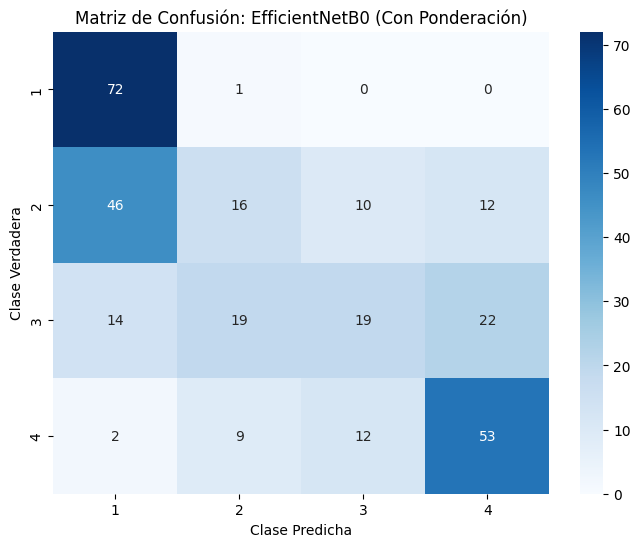



--- Prueba del Modelo Único ---
Modelo: EfficientNetB0, Precisión: 0.4723, Tiempo: 1033.54 s
Found 1543 images belonging to 4 classes.

--- Prueba de Predicción con EfficientNetB0 ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step


✅ Imagen: /content/drive/MyDrive/Datasets_Ulceras/stage_4_2274.jpg (Cargada exitosamente)
RESULTADO: Clasificado como: '4'
CONFIANZA: 87.13%
✅ ¡MODELO GUARDADO EXITOSAMENTE! Lo puedes encontrar en: /content/drive/MyDrive/Modelos_Ulceras_TFLite/modelo_efb0_final.h5


In [26]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils import class_weight
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import time
import shutil # Necesario para la copia
import zipfile
import io

from google.colab import drive

# --- 3. SCRIPT PRINCIPAL DE ENTRENAMIENTO Y EVALUACIÓN ---

def calculate_class_weights(generator):
    """Calcula los pesos inversos de frecuencia para el desbalance de clases."""
    generator.reset()
    class_indices = generator.classes

    weights = class_weight.compute_class_weight(
        class_weight='balanced',
        classes=np.unique(class_indices),
        y=class_indices
    )
    class_weights_dict = dict(enumerate(weights))

    print("   Pesos de clase calculados (mayor peso a clases minoritarias):")
    for idx, weight in class_weights_dict.items():
        class_name = list(generator.class_indices.keys())[idx]
        print(f"      Clase {class_name}: Peso {weight:.2f}")

    return class_weights_dict

def run_transfer_learning_experiment(model_name, model_settings, dataset_path, batch_size, val_split,
                                     initial_epochs, fine_tune_epochs, fine_tune_learning_rate, DROPOUT_RATE):

    BaseModel = model_settings['func']
    IMG_SIZE = model_settings['size']
    preprocess_func = model_settings['preprocess']

    train_generator = None
    validation_generator = None

    print(f"\n--- Iniciando Experimento con {model_name} (Tamaño: {IMG_SIZE[0]}x{IMG_SIZE[1]}) ---")
    start_time = time.time()

    # 1. Generador de Datos con Aumento en Tiempo Real
    datagen = ImageDataGenerator(
        preprocessing_function=preprocess_func, validation_split=val_split,
        rotation_range=30, width_shift_range=0.2, height_shift_range=0.2,
        brightness_range=[0.8, 1.2], zoom_range=0.25, horizontal_flip=True,
        fill_mode='nearest'
    )

    try:
        train_generator = datagen.flow_from_directory(
            dataset_path, target_size=IMG_SIZE, batch_size=batch_size,
            class_mode='categorical', subset='training'
        )

        validation_generator = datagen.flow_from_directory(
            dataset_path, target_size=IMG_SIZE, batch_size=batch_size,
            class_mode='categorical', subset='validation', shuffle=False
        )
    except Exception as e:
        print(f"❌ ERROR: No se pudieron cargar los datos para {model_name}. Detalle: {e}")
        return model_name, 0.0, 0.0, None

    # 2. CALCULAR PESOS
    class_weights = calculate_class_weights(train_generator)

    NUM_CLASSES = train_generator.num_classes
    CLASS_NAMES = list(train_generator.class_indices.keys())

    # 3. Construir el Modelo
    base_model = BaseModel(input_shape=IMG_SIZE + (3,), include_top=False, weights='imagenet')

    x = base_model.output
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(DROPOUT_RATE)(x) # 🚨 Dropout ajustado a 0.6
    predictions = tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')(x)
    model = tf.keras.models.Model(inputs=base_model.input, outputs=predictions)

    # -----------------------------------------------------------
    # FASE 1: ENTRENAMIENTO INICIAL (Capas superiores congeladas)
    # -----------------------------------------------------------
    print(f"\nFASE 1/2: Entrenamiento de capas superiores (congeladas). Épocas: {initial_epochs}")
    base_model.trainable = False
    model.compile(optimizer='Adam', loss='categorical_crossentropy', metrics=['accuracy'])

    history = model.fit(
        train_generator, epochs=initial_epochs, validation_data=validation_generator,
        class_weight=class_weights, verbose=1
    )

    # -----------------------------------------------------------
    # FASE 2: AJUSTE FINO (FINE-TUNING)
    # -----------------------------------------------------------
    print(f"\nFASE 2/2: Ajuste Fino (Fine-Tuning) de la red base. Épocas: {fine_tune_epochs}")

    # Descongelar Capas
    base_model.trainable = True
    FINE_TUNE_LAYER = int(len(base_model.layers) * 0.20)
    for layer in base_model.layers[:FINE_TUNE_LAYER]:
        layer.trainable = False

    print(f"   Capas congeladas: {FINE_TUNE_LAYER}. Capas ajustadas: {len(base_model.layers) - FINE_TUNE_LAYER}")

    # Recompilar con Tasa de Aprendizaje ULTRABAJA
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=fine_tune_learning_rate), # 🚨 LR ajustada a 5e-6
        loss='categorical_crossentropy', metrics=['accuracy']
    )

    # Continuar Entrenamiento
    total_epochs = initial_epochs + fine_tune_epochs

    model.fit(
        train_generator, epochs=total_epochs, initial_epoch=history.epoch[-1],
        validation_data=validation_generator, class_weight=class_weights, verbose=1
    )

    # 4. Evaluación y Matriz de Confusión
    validation_generator.reset()
    Y_pred = model.predict(validation_generator)
    y_pred_classes = np.argmax(Y_pred, axis=1)
    y_true_classes = validation_generator.classes

    loss, accuracy = model.evaluate(validation_generator, verbose=0)
    end_time = time.time()
    elapsed_time = end_time - start_time

    print(f"\n--- Resultados Finales de {model_name} ---")
    print(f"Precisión Final: {accuracy:.4f}")

    # Generar y mostrar Matriz de Confusión (MC)
    cm = confusion_matrix(y_true_classes, y_pred_classes)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.xlabel('Clase Predicha')
    plt.ylabel('Clase Verdadera')
    plt.title(f'Matriz de Confusión: {model_name} (Con Ponderación)')
    plt.show() # Esta línea finaliza el bloque de la Matriz de Confusión

    return model_name, accuracy, elapsed_time, model # ADDED THIS LINE

# --- Función de Predicción ---
def predict_single_image(model, img_path, class_names, img_size, preprocess_func, model_name):
    print(f"\n--- Prueba de Predicción con {model_name} ---")
    if not os.path.exists(img_path):
        print(f"❌ ERROR CRÍTICO: El archivo de imagen NO fue encontrado en Drive: {img_path}")
        return

    try:
        img = tf.keras.preprocessing.image.load_img(img_path, target_size=img_size)
        img_array = tf.keras.preprocessing.image.img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0)
        processed_img = preprocess_func(img_array)
        predictions = model.predict(processed_img)

        predicted_class_index = np.argmax(predictions[0])
        predicted_class = class_names[predicted_class_index]
        confidence = predictions[0][predicted_class_index]

        print(f"✅ Imagen: {img_path} (Cargada exitosamente)")
        print(f"RESULTADO: Clasificado como: '{predicted_class}'")
        print(f"CONFIANZA: {(confidence * 100):.2f}%")

    except Exception as e:
        print(f"❌ Error durante el procesamiento o predicción: {e}")

# --- Ejecución Principal (Solo EfficientNetB0) ---
if __name__ == '__main__':

    print("\n=======================================================")
    print("      INICIANDO PRUEBA AISLADA: EfficientNetB0         ")
    print("=======================================================")

    # Las variables de hiperparámetros se cargan desde la Celda 2
    name = "EfficientNetB0"
    settings = MODEL_SETTINGS[name]

    # 🚨 Llamada final utilizando las variables cargadas desde la Celda 2 🚨
    model_name, accuracy, train_time, trained_model = run_transfer_learning_experiment(
        name, settings, DATASET_PATH_GLOBAL, BATCH_SIZE, VALIDATION_SPLIT,
        initial_epochs, fine_tune_epochs, fine_tune_learning_rate, DROPOUT_RATE
    )

    # Si el entrenamiento fue exitoso, ejecutamos la predicción final
    if accuracy > 0:

        print("\n\n--- Prueba del Modelo Único ---")
        print(f"Modelo: {model_name}, Precisión: {accuracy:.4f}, Tiempo: {train_time:.2f} s")

        temp_datagen = ImageDataGenerator()
        temp_generator = temp_datagen.flow_from_directory(
            DATASET_PATH_GLOBAL, target_size=settings['size'], batch_size=1, shuffle=False
        )
        CLASS_NAMES = list(temp_generator.class_indices.keys())

        predict_single_image(
            trained_model, RUTA_IMAGEN_NUEVA, CLASS_NAMES,
            settings['size'], settings['preprocess'],
            settings['func'].__name__
        )
# --- GUARDAR EL MODELO PARA NO PERDERLO ---
ruta_guardado_h5 = '/content/drive/MyDrive/Modelos_Ulceras_TFLite/modelo_efb0_final.h5'

# Creamos la carpeta en Drive si no existe
os.makedirs('/content/drive/MyDrive/Modelos_Ulceras_TFLite', exist_ok=True)

# Guardamos el modelo en formato legacy .h5 para máxima compatibilidad
trained_model.save(ruta_guardado_h5)

print(f"✅ ¡MODELO GUARDADO EXITOSAMENTE! Lo puedes encontrar en: {ruta_guardado_h5}")

In [27]:
import tensorflow as tf

# Cargar el modelo .h5
ruta_h5 = '/content/drive/MyDrive/Modelos_Ulceras_TFLite/modelo_efb0_final.h5'
model = tf.keras.models.load_model(ruta_h5)

# Crear el conversor
converter = tf.lite.TFLiteConverter.from_keras_model(model)

# CONFIGURACIÓN DE COMPATIBILIDAD FORZADA
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS # Solo operaciones estándar
]

# ESTO ES LO NUEVO: Evita que se usen metadatos de versiones nuevas
converter._experimental_lower_tensor_list_ops = True
converter.target_spec.supported_types = [tf.float32]

# Convertir
tflite_model = converter.convert()

# Guardar con un nombre que SEPAS que es el nuevo (ej: final_v4.tflite)
ruta_en_drive = '/content/drive/MyDrive/Modelos_Ulceras_TFLite/clasificador_final_v4.tflite'

with open(ruta_en_drive, 'wb') as f:
    f.write(tflite_model)

print(f"✅ ¡AHORA SÍ! El archivo está en tu Drive: {ruta_en_drive}")

Saved artifact at '/tmp/tmpfb4gc64j'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_2')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  136936572486288: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  136936572486096: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  136935893381200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136935893383312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136935893383504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136935893380816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136935893378896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136935893377168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136935893372944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136935893379088: TensorSpec(shape=(), dtype=tf.resource, name=Non

Transformación a TFlite

In [28]:
import tensorflow as tf
import os

# 1. RUTA DEL MODELO QUE YA TIENES EN DRIVE
# Cambia 'mi_modelo_entrenado.h5' por el nombre real de tu archivo en Drive
RUTA_MODELO_ORIGINAL = '/content/drive/MyDrive/Modelos_Ulceras_TFLite/modelo_efb0_final.h5' # CORREGIDO: Usar el modelo .h5

# 2. CARGAR EL MODELO A LA MEMORIA
if os.path.exists(RUTA_MODELO_ORIGINAL):
    model_to_convert = tf.keras.models.load_model(RUTA_MODELO_ORIGINAL)
    print("✅ Modelo cargado exitosamente desde Drive.")

    # 3. CONFIGURAR EL CONVERSOR CON EL MODELO CARGADO
    converter = tf.lite.TFLiteConverter.from_keras_model(model_to_convert)

    # AJUSTE CRÍTICO DE COMPATIBILIDAD PARA ANDROID (Arregla el Opcode 12)
    converter.target_spec.supported_ops = [
        tf.lite.OpsSet.TFLITE_BUILTINS,
        tf.lite.OpsSet.SELECT_TF_OPS
    ]
    converter.optimizations = [tf.lite.Optimize.DEFAULT]

    # 4. EJECUTAR CONVERSIÓN
    tflite_model = converter.convert()

    # 5. GUARDAR EL NUEVO ARCHIVO COMPATIBLE
    NUEVA_RUTA_TFLITE = '/content/drive/MyDrive/efficientnet_ulceras_v2_fijo.tflite'
    with open(NUEVA_RUTA_TFLITE, 'wb') as f:
        f.write(tflite_model)

    print(f"✅ ¡LISTO! Descarga este archivo: {NUEVA_RUTA_TFLITE}")
else:
    print("❌ No se encontró el archivo. Revisa que la ruta en Drive sea correcta.")

✅ Modelo cargado exitosamente desde Drive.
Saved artifact at '/tmp/tmp5boxzp68'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_2')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  136935868734096: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  136935868734288: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  136934992472080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136934992471312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136934992471504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136934992470544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136934992470736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136934992472848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136934992478032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136934992471120: Tenso

In [29]:
import numpy as np
from PIL import Image
from tensorflow.keras.applications.efficientnet import preprocess_input

# --- 1. DEFINICIÓN DE PARÁMETROS ---

# ¡ADAPTA ESTA LISTA DE CLASES! Deben estar en el mismo orden que el generador.
CLASS_NAMES = ['Clase_1', 'Clase_2', 'Clase_3', 'Clase_4'] # Reemplaza con tus clases
IMG_SIZE = (224, 224)
RUTA_IMAGEN_NUEVA = r'/content/drive/MyDrive/Datasets_Ulceras/stage_4_2274.jpg'
TFLITE_MODEL_PATH = '/content/drive/MyDrive/efficientnet_ulceras_v2_fijo.tflite' # DEFINIDO: Ruta al modelo TFLite

# --- 2. FUNCIÓN DE INFERENCIA ---

def run_tflite_inference(tflite_model_path, image_path, class_names):

    # Cargar el intérprete TFLite
    interpreter = tf.lite.Interpreter(model_path=tflite_model_path)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()

    # Cargar, reescalar y normalizar la imagen (Simulando la App Móvil)
    try:
        img = Image.open(image_path).convert('RGB')
        img = img.resize(IMG_SIZE)
        img_array = np.array(img, dtype=np.float32)
        img_array = np.expand_dims(img_array, axis=0)

        # 🚨 Preprocesamiento de EfficientNetB0 (CRÍTICO)
        preprocessed_img = preprocess_input(img_array)

    except FileNotFoundError:
        print(f"❌ ERROR: No se encontró la imagen de prueba: {image_path}")
        return

    # Ejecutar la inferencia
    interpreter.set_tensor(input_details[0]['index'], preprocessed_img)
    interpreter.invoke()

    # Obtener los resultados
    output_data = interpreter.get_tensor(output_details[0]['index'])

    # Post-procesamiento
    probabilities = tf.nn.softmax(output_data[0])
    predicted_index = np.argmax(probabilities)
    predicted_class = class_names[predicted_index]
    confidence = probabilities[predicted_index] * 100

    print("\n--- Resultado de la Predicción TFLite ---")
    print(f"Clase Predicha: {predicted_class}")
    print(f"Nivel de Confianza: {confidence:.2f}%")
    print("----------------------------------------")

# --- 3. EJECUTAR PRUEBA ---
run_tflite_inference(TFLITE_MODEL_PATH, RUTA_IMAGEN_NUEVA, CLASS_NAMES)


--- Resultado de la Predicción TFLite ---
Clase Predicha: Clase_4
Nivel de Confianza: 42.64%
----------------------------------------


/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [30]:
# Asumiendo que 'temp_generator' fue el último generador creado en la Celda 3 para la predicción final
print("Orden de Clases del Generador:")
print(list(temp_generator.class_indices.keys()))

Orden de Clases del Generador:
['1', '2', '3', '4']


Validación con imagenes externas

In [31]:
import numpy as np
import tensorflow as tf
from PIL import Image
from tensorflow.keras.applications.efficientnet import preprocess_input
import os

# --- 1. CONFIGURACIÓN ---
# Actualiza CLASS_NAMES para que coincida con el orden de clases real del entrenamiento
# (Obtenido del output de la celda O7Ugijj4LYIW)
CLASS_NAMES = ['1', '2', '3', '4']  # CORREGIDO: Usar los nombres de clase reales
IMG_SIZE = (224, 224)
RUTA_MODELO_TFLITE = '/content/drive/MyDrive/efficientnet_ulceras_v2_fijo.tflite'
CARPETA_EXTERNAS = '/content/drive/MyDrive/Datasets_Ulceras/imagenes_externas/'

# --- 2. FUNCIÓN DE INFERENCIA ---
def run_tflite_inference(tflite_model_path, image_path, class_names):
    # Añadir una verificación para el archivo TFLite
    if not os.path.exists(tflite_model_path):
        print(f"❌ ERROR: El archivo TFLite NO se encontró en la ruta: {tflite_model_path}")
        return None, None
    if os.path.getsize(tflite_model_path) == 0:
        print(f"❌ ERROR: El archivo TFLite parece estar vacío o corrupto: {tflite_model_path}")
        return None, None

    try:
        interpreter = tf.lite.Interpreter(model_path=tflite_model_path)
    except Exception as e:
        print(f"❌ ERROR: Fallo al inicializar el intérprete TFLite para '{tflite_model_path}'. Detalle: {e}")
        print("Esto podría indicar un archivo TFLite corrupto o un problema de compatibilidad.")
        return None, None

    interpreter.allocate_tensors()
    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()

    try:
        img = Image.open(image_path).convert('RGB')
        img = img.resize(IMG_SIZE)
        img_array = np.array(img, dtype=np.float32)
        img_array = np.expand_dims(img_array, axis=0)
        preprocessed_img = preprocess_input(img_array)
    except FileNotFoundError:
        print(f"❌ ERROR: No se encontró: {image_path}")
        return None, None

    interpreter.set_tensor(input_details[0]['index'], preprocessed_img)
    interpreter.invoke()
    output_data = interpreter.get_tensor(output_details[0]['index'])
    probabilities = tf.nn.softmax(output_data[0])
    predicted_index = np.argmax(probabilities)
    predicted_class = class_names[predicted_index]
    confidence = probabilities[predicted_index] * 100

    # Mostrar también la distribución de probabilidades
    print(f"\n📷 Imagen: {os.path.basename(image_path)}")
    print(f"   Clase predicha: {predicted_class}")
    print(f"   Confianza: {confidence:.2f}%")
    print(f"   Distribución completa:")
    for i, prob in enumerate(probabilities):
        print(f"      {class_names[i]}: {prob*100:.2f}%")

    return predicted_class, confidence

# --- 3. EJECUTAR PRUEBAS SOBRE TODAS LAS IMÁGENES EXTERNAS ---
if os.path.exists(CARPETA_EXTERNAS):
    archivos = sorted([f for f in os.listdir(CARPETA_EXTERNAS) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])

    if len(archivos) == 0:
        print("⚠️ No hay imágenes en la carpeta externa.")
    else:
        print(f"\n{'='*60}")
        print(f"  PRUEBAS CON IMÁGENES EXTERNAS AL DATASET ({len(archivos)} imágenes)")
        print(f"{'='*60}")

        resultados = []
        for archivo in archivos:
            ruta = os.path.join(CARPETA_EXTERNAS, archivo)
            clase, conf = run_tflite_inference(RUTA_MODELO_TFLITE, ruta, CLASS_NAMES)
            if clase is not None:
                resultados.append({
                    'archivo': archivo,
                    'clase_predicha': clase,
                    'confianza': conf
                })

        # Resumen final
        print(f"\n{'='*60}")
        print("  RESUMEN DE PRUEBAS EXTERNAS")
        print(f"{'='*60}")
        for r in resultados:
            print(f"  {r['archivo']:40} → {r['clase_predicha']:10} ({r['confianza']:.2f}%)")

        # Estadísticas
        if resultados:
            conf_promedio = np.mean([r['confianza'] for r in resultados])
            conf_max = max([r['confianza'] for r in resultados])
            conf_min = min([r['confianza'] for r in resultados])
            print(f"\n  Confianza promedio: {conf_promedio:.2f}%")
            print(f"  Confianza máxima:   {conf_max:.2f}%")
            print(f"  Confianza mínima:   {conf_min:.2f}%")
else:
    print(f"❌ No existe la carpeta: {CARPETA_EXTERNAS}")


  PRUEBAS CON IMÁGENES EXTERNAS AL DATASET (4 imágenes)

📷 Imagen: UPPGrado 3.jpg
   Clase predicha: 4
   Confianza: 33.29%
   Distribución completa:
      1: 19.07%
      2: 21.49%
      3: 26.16%
      4: 33.29%

📷 Imagen: UPPGrado1.jpg
   Clase predicha: 1
   Confianza: 32.26%
   Distribución completa:
      1: 32.26%
      2: 25.69%
      3: 21.21%
      4: 20.84%

📷 Imagen: UPPGrado2.jpg
   Clase predicha: 2
   Confianza: 30.86%
   Distribución completa:
      1: 23.84%
      2: 30.86%
      3: 23.99%
      4: 21.31%

📷 Imagen: UPPGrsdo 4.jpg
   Clase predicha: 4
   Confianza: 37.46%
   Distribución completa:
      1: 18.68%
      2: 18.86%
      3: 25.01%
      4: 37.46%

  RESUMEN DE PRUEBAS EXTERNAS
  UPPGrado 3.jpg                           → 4          (33.29%)
  UPPGrado1.jpg                            → 1          (32.26%)
  UPPGrado2.jpg                            → 2          (30.86%)
  UPPGrsdo 4.jpg                           → 4          (37.46%)

  Confianza promedio: